# MAG7 Context-Gated Full LTN

This is the full LTN version of the MAG7 context experiment.

It mirrors the oil context-gated setup in spirit:

- Qwen headline/event predicates are reused from the existing MAG7 abnormal-return run.
- Market and news-flow context features are added around each event.
- Neural LTN predicates are trained for `Bullish(x)`, `Bearish(x)`, and `Neutral(x)`.
- Logical constraints are imposed with `ltn.Predicate`, `ltn.Variable`, and `ltn.fuzzy_ops`.
- Variants test whether signal comes from Qwen semantics, market context, or context-gated Qwen rules.

The notebook does **not** rerun Qwen and does **not** use sklearn models.


In [1]:
from __future__ import annotations

import json
from itertools import combinations
from pathlib import Path
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import binomtest

import ltn

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 240)

# Use the folder the notebook is currently running from.
WORK_DIR = Path.cwd()

# Search only in the current folder for required input files.
EVENTS_PATH = WORK_DIR / "refined_event_returns.parquet"
MAG7_PRICE_PATH = WORK_DIR / "mag7_daily_prices.parquet"
SP500_PRICE_PATH = WORK_DIR / "sp500_daily_prices.parquet"

required_files = {
    "refined_event_returns.parquet": EVENTS_PATH,
    "mag7_daily_prices.parquet": MAG7_PRICE_PATH,
    "sp500_daily_prices.parquet": SP500_PRICE_PATH,
}

missing = [name for name, path in required_files.items() if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing required file(s) in the current folder:\n"
        + "\n".join(f"- {name}" for name in missing)
        + f"\n\nCurrent folder is:\n{WORK_DIR}"
    )

# Write all outputs to the current folder.
OUTPUT_DIR = WORK_DIR / "16_mag7_full_classify_final_final_simple_return"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY_HORIZON = 3
RETURN_THRESHOLD = 0.005
DISCOVERY = ("2023-01-01", "2024-12-31")
VALIDATION = ("2025-01-01", "2025-12-31")
TEST = ("2026-01-01", "2026-06-01")

EPOCHS = 500
LR = 0.01
LOGIC_WEIGHT = 0.30
SEED = 7
ROBUST_SEEDS = [1, 2, 3, 4, 5, 7, 11, 13, 17, 19]

LABELS = ["bearish", "bullish", "neutral"]
ANTECEDENT_THRESHOLD = 0.50
MIN_DISCOVERY_EVENTS = 6
MIN_VALIDATION_EVENTS = 5
MIN_DISCOVERY_ACCURACY = 40.0
MIN_VALIDATION_ACCURACY = 40.0

SAVE_OUTPUTS = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("working folder:", WORK_DIR)
print("events:", EVENTS_PATH)
print("mag7 prices:", MAG7_PRICE_PATH)
print("sp500 prices:", SP500_PRICE_PATH)
print("output:", OUTPUT_DIR)
print("ltn:", getattr(ltn, "__version__", "unknown"))
print("torch:", torch.__version__, "device:", device)

working folder: /home/jovyan/Stock-Sentiment-Prediction
events: /home/jovyan/Stock-Sentiment-Prediction/refined_event_returns.parquet
mag7 prices: /home/jovyan/Stock-Sentiment-Prediction/mag7_daily_prices.parquet
sp500 prices: /home/jovyan/Stock-Sentiment-Prediction/sp500_daily_prices.parquet
output: /home/jovyan/Stock-Sentiment-Prediction/16_mag7_full_classify_final_final_simple_return
ltn: unknown
torch: 2.12.1+cu126 device: cuda


In [2]:
def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

reset_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:
    torch.use_deterministic_algorithms(True)
except Exception as e:
    print("Could not force all deterministic algorithms:", e)

## Load Existing Qwen MAG7 Events


In [3]:
events_all = pd.read_parquet(EVENTS_PATH).copy()
prices = pd.read_parquet(MAG7_PRICE_PATH).copy()
sp500 = pd.read_parquet(SP500_PRICE_PATH).copy()

events_all["time_published"] = pd.to_datetime(events_all["time_published"], utc=True)
events_all["event_date"] = pd.to_datetime(events_all["event_date"])
prices["date"] = pd.to_datetime(prices["date"])
sp500["date"] = pd.to_datetime(sp500["date"])


def build_simple_return_table(price_df: pd.DataFrame, horizons) -> pd.DataFrame:
    frames = []
    for horizon in sorted({int(h) for h in horizons if pd.notna(h)}):
        for ticker, group in price_df.groupby("ticker"):
            g = group.sort_values("date").copy()
            px = pd.to_numeric(g["adj_close"], errors="coerce")
            g["horizon_days"] = horizon
            g["event_date"] = g["date"]
            g["prev_close"] = px.shift(1)
            g["future_close"] = px.shift(-(horizon - 1))
            g["simple_return"] = g["future_close"] / g["prev_close"] - 1.0
            frames.append(g[["ticker", "event_date", "horizon_days", "simple_return", "prev_close", "future_close"]])
    return pd.concat(frames, ignore_index=True)


def realised_label_from_return(value: float, threshold: float = RETURN_THRESHOLD) -> str:
    if pd.isna(value):
        return "neutral"
    if value > threshold:
        return "bullish"
    if value < -threshold:
        return "bearish"
    return "neutral"

simple_returns = build_simple_return_table(prices, events_all["horizon_days"].dropna().astype(int).unique())
events_all = events_all.drop(columns=["simple_return", "prev_close", "future_close"], errors="ignore").merge(
    simple_returns,
    on=["ticker", "event_date", "horizon_days"],
    how="left",
)
missing_simple_returns = int(events_all["simple_return"].isna().sum())
if missing_simple_returns:
    raise ValueError(f"Missing simple returns for {missing_simple_returns} event rows")

events = (
    events_all.loc[events_all["horizon_days"].eq(PRIMARY_HORIZON)]
    .drop_duplicates("event_id")
    .sort_values(["ticker", "time_published"])
    .reset_index(drop=True)
)
events["target_label"] = events["simple_return"].map(lambda x: realised_label_from_return(float(x), RETURN_THRESHOLD))

display(events.groupby(events["event_date"].dt.year)["target_label"].value_counts().unstack(fill_value=0))
display(events[[
    "ticker", "time_published", "event_date", "representative_title",
    "expected_label", "target_label", "simple_return",
    "event_subtype", "valuation_channel", "materiality_strength", "novelty",
]].head())



target_label,bearish,bullish,neutral
event_date,,,
2023,23,22,10
2024,50,57,15
2025,51,69,20
2026,33,25,5


,ticker,time_published,event_date,representative_title,expected_label,target_label,simple_return,event_subtype,valuation_channel,materiality_strength,novelty
0,AAPL,2023-07-03 23:40:57+00:00,2023-07-05,"Settlement checks in the mail from Roundup, Ep...",neutral,bearish,-0.009249,lawsuit_settlement,legal_liability,medium,material_update
1,AAPL,2023-07-19 22:53:14+00:00,2023-07-20,Report: Apple built ‘Apple GPT’ chatbot using ...,bullish,bearish,-0.012045,product_launch,product_adoption,high,new_event
2,AAPL,2023-08-04 06:26:00+00:00,2023-08-04,"Apple sees sales slump continuing, shares drop...",bearish,bearish,-0.059476,demand_decrease,revenue_demand,high,material_update
3,AAPL,2023-08-29 00:00:00+00:00,2023-08-29,"Apellis to lay off 25% of staff, trim research...",bearish,bullish,0.042622,layoffs_cost_cutting,cost_margin,high,material_update
4,AAPL,2023-09-22 00:00:00+00:00,2023-09-22,Calix taps Jabil as part of $42B+ broadband ma...,neutral,bearish,-0.011326,partnership_customer_deal,unclear,medium,material_update


## Add Market And News-Flow Context


In [4]:
def add_price_context(price_df: pd.DataFrame, prefix: str, group_col: str | None = None) -> pd.DataFrame:
    out = price_df.sort_values(([group_col] if group_col else []) + ["date"]).copy()
    grouped = out.groupby(group_col, group_keys=False) if group_col else [(None, out)]
    
    parts = []
    
    for _, g in grouped:
        g = g.sort_values("date").copy()
        px = pd.to_numeric(g["adj_close"], errors="coerce")
        daily = px.pct_change()
        
        for window in [1, 3, 5, 20]:
            g[f"{prefix}_ret_{window}d_pre"] = px.pct_change(window).shift(1)
        
        g[f"{prefix}_abs_ret_1d_pre"] = daily.abs().shift(1)
        g[f"{prefix}_vol_5d_pre"] = daily.rolling(5).std().shift(1)
        g[f"{prefix}_vol_20d_pre"] = daily.rolling(20).std().shift(1)
        
        parts.append(g)
        
    return pd.concat(parts, ignore_index=True)

ticker_ctx = add_price_context(prices, "ticker", "ticker")
sp500_ctx = add_price_context(sp500, "sp500", None).drop(columns=["ticker"], errors="ignore")

ctx = events.merge(
    ticker_ctx[[
        "ticker", "date", "ticker_ret_1d_pre", "ticker_ret_3d_pre", "ticker_ret_5d_pre", "ticker_ret_20d_pre",
        "ticker_abs_ret_1d_pre", "ticker_vol_5d_pre", "ticker_vol_20d_pre",
    ]],
    left_on=["ticker", "event_date"],
    right_on=["ticker", "date"],
    how="left",
).drop(columns=["date"], errors="ignore")

ctx = ctx.merge(
    sp500_ctx[[
        "date", "sp500_ret_1d_pre", "sp500_ret_3d_pre", "sp500_ret_5d_pre", "sp500_ret_20d_pre",
        "sp500_abs_ret_1d_pre", "sp500_vol_5d_pre", "sp500_vol_20d_pre",
    ]],
    left_on="event_date",
    right_on="date",
    how="left",
).drop(columns=["date"], errors="ignore")


for h in ["1d", "3d", "5d", "20d"]:
    ctx[f"relative_ret_{h}_pre"] = ctx[f"ticker_ret_{h}_pre"] - ctx[f"sp500_ret_{h}_pre"]

ctx = ctx.sort_values(["ticker", "time_published"]).reset_index(drop=True)
ctx["event_density_ticker_7d"] = 0.0
ctx["event_density_ticker_30d"] = 0.0
ctx["similar_density_ticker_30d"] = 0.0

for ticker, group in ctx.groupby("ticker"):
    for idx, ts, subtype, channel in zip(
        group.index,
        group["time_published"],
        group["event_subtype"],
        group["valuation_channel"],
    ):
        prev = group.loc[group["time_published"].lt(ts)]
        last7 = prev.loc[prev["time_published"].ge(ts - pd.Timedelta(days=7))]
        last30 = prev.loc[prev["time_published"].ge(ts - pd.Timedelta(days=30))]
        similar30 = last30.loc[
            last30["event_subtype"].eq(subtype)
            | last30["valuation_channel"].eq(channel)
        ]

        ctx.loc[idx, "event_density_ticker_7d"] = len(last7)
        ctx.loc[idx, "event_density_ticker_30d"] = len(last30)
        ctx.loc[idx, "similar_density_ticker_30d"] = len(similar30)


hour = ctx["time_published"].dt.hour + ctx["time_published"].dt.minute / 60
ctx["hour_sin_01"] = (np.sin(2 * np.pi * hour / 24) + 1) / 2
ctx["hour_cos_01"] = (np.cos(2 * np.pi * hour / 24) + 1) / 2
ctx["is_monday"] = (ctx["time_published"].dt.weekday == 0).astype(float)
ctx["is_friday"] = (ctx["time_published"].dt.weekday == 4).astype(float)

display(ctx[[
    "ticker", "event_date", "target_label", "expected_label",
    "relative_ret_5d_pre", "sp500_vol_5d_pre", "ticker_vol_5d_pre",
    "event_density_ticker_7d", "event_density_ticker_30d", "similar_density_ticker_30d",
    "hour_sin_01", "hour_cos_01", "is_monday", "is_friday",
]].head(10))

,ticker,event_date,target_label,expected_label,relative_ret_5d_pre,sp500_vol_5d_pre,ticker_vol_5d_pre,event_density_ticker_7d,event_density_ticker_30d,similar_density_ticker_30d,hour_sin_01,hour_cos_01,is_monday,is_friday
0,AAPL,2023-07-05,bearish,neutral,0.009523,0.005807,0.011915,0.0,0.0,0.0,0.456422,0.998097,1.0,0.0
1,AAPL,2023-07-20,bearish,bullish,0.007166,0.003793,0.007295,0.0,1.0,0.0,0.355902,0.978786,0.0,0.0
2,AAPL,2023-08-04,bearish,bearish,-0.002781,0.008558,0.010984,0.0,1.0,0.0,0.996786,0.443398,0.0,1.0
3,AAPL,2023-08-29,bullish,bearish,0.017115,0.009786,0.018306,0.0,1.0,0.0,0.500000,1.000000,0.0,0.0
4,AAPL,2023-09-22,bearish,neutral,0.028568,0.007071,0.014146,0.0,1.0,0.0,0.500000,1.000000,0.0,1.0
5,AAPL,2023-10-30,bullish,bullish,-0.001674,0.008593,0.013354,0.0,0.0,0.0,0.402455,0.009607,0.0,0.0
6,AAPL,2023-11-14,bullish,bearish,0.021998,0.008614,0.012786,0.0,1.0,0.0,0.500000,1.000000,0.0,0.0
7,AAPL,2023-11-30,neutral,bullish,-0.009392,0.002293,0.004825,0.0,1.0,0.0,0.500000,1.000000,0.0,0.0
8,AAPL,2023-12-19,bearish,bearish,-0.011525,0.005160,0.009768,0.0,1.0,0.0,0.441231,0.996534,1.0,0.0
9,AAPL,2024-01-10,neutral,bearish,-0.005576,0.008351,0.014335,0.0,1.0,0.0,0.500000,1.000000,0.0,0.0


## Prepare LTN Feature Truth Values And Splits


In [5]:
def assign_period(d):
    d = pd.Timestamp(d)
    if pd.Timestamp(DISCOVERY[0]) <= d <= pd.Timestamp(DISCOVERY[1]):
        return "discovery"
    if pd.Timestamp(VALIDATION[0]) <= d <= pd.Timestamp(VALIDATION[1]):
        return "validation"
    if pd.Timestamp(TEST[0]) <= d <= pd.Timestamp(TEST[1]):
        return "test"
    return "outside"

ctx["period"] = ctx["event_date"].map(assign_period)

fit_mask = ctx["period"].eq("discovery")

def fit_abs_scale(col, q=0.80):
    s = pd.to_numeric(ctx.loc[fit_mask, col], errors="coerce").replace([np.inf, -np.inf], np.nan)
    scale = s.abs().quantile(q)
    return float(scale) if np.isfinite(scale) and scale != 0 else 1.0

def fit_quantile(col, q, fallback=1.0):
    s = pd.to_numeric(ctx.loc[fit_mask, col], errors="coerce").replace([np.inf, -np.inf], np.nan)
    value = s.quantile(q)
    return float(value) if np.isfinite(value) and value != 0 else fallback

def soft_pos_with_scale(s, scale):
    s = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    return (s.clip(lower=0) / scale).clip(0, 1).fillna(0)

def soft_neg_with_scale(s, scale):
    return soft_pos_with_scale(-pd.to_numeric(s, errors="coerce"), scale)

def soft_low_with_cutoff(s, cutoff):
    s = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    return (1 - (s / cutoff)).clip(0, 1).fillna(0)

def soft_high_with_cutoff(s, cutoff):
    s = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    return (s / cutoff - 1).clip(0, 1).fillna(0)

ticker_5d_scale = fit_abs_scale("ticker_ret_5d_pre")
market_5d_scale = fit_abs_scale("sp500_ret_5d_pre")
relative_5d_scale = fit_abs_scale("relative_ret_5d_pre")

ctx["ticker_prior_up_5d"] = soft_pos_with_scale(ctx["ticker_ret_5d_pre"], ticker_5d_scale)
ctx["ticker_prior_down_5d"] = soft_neg_with_scale(ctx["ticker_ret_5d_pre"], ticker_5d_scale)
ctx["market_prior_up_5d"] = soft_pos_with_scale(ctx["sp500_ret_5d_pre"], market_5d_scale)
ctx["market_prior_down_5d"] = soft_neg_with_scale(ctx["sp500_ret_5d_pre"], market_5d_scale)
ctx["relative_prior_up_5d"] = soft_pos_with_scale(ctx["relative_ret_5d_pre"], relative_5d_scale)
ctx["relative_prior_down_5d"] = soft_neg_with_scale(ctx["relative_ret_5d_pre"], relative_5d_scale)

ctx["quiet_market_5d"] = soft_low_with_cutoff(
    ctx["sp500_vol_5d_pre"],
    fit_quantile("sp500_vol_5d_pre", 0.40),
)
ctx["volatile_market_5d"] = soft_high_with_cutoff(
    ctx["sp500_vol_5d_pre"],
    fit_quantile("sp500_vol_5d_pre", 0.70),
)
ctx["quiet_ticker_5d"] = soft_low_with_cutoff(
    ctx["ticker_vol_5d_pre"],
    fit_quantile("ticker_vol_5d_pre", 0.40),
)
ctx["volatile_ticker_5d"] = soft_high_with_cutoff(
    ctx["ticker_vol_5d_pre"],
    fit_quantile("ticker_vol_5d_pre", 0.70),
)


for col in ["event_density_ticker_7d", "event_density_ticker_30d", "similar_density_ticker_30d"]:
    denom = max(ctx.loc[fit_mask, col].quantile(0.95), 1)
    ctx[col + "_01"] = (ctx[col] / denom).clip(0, 1)

ctx["novel_context_30d"] = (1 - ctx["similar_density_ticker_30d_01"]).clip(0, 1)

dummy_parts = []
dummy_cols = []

categorical_cols = [
    "expected_label",
    "event_subtype",
    "valuation_channel",
    "materiality_strength",
    "novelty",
]

for col in categorical_cols:
    categories = sorted(set(ctx.loc[fit_mask, col].fillna("missing").astype(str)))
    values = ctx[col].fillna("missing").astype(str)

    for category in categories:
        dummy_name = f"{col}_{category}"
        dummy_parts.append(values.eq(category).astype(float).rename(dummy_name))
        dummy_cols.append(dummy_name)

dummies = pd.concat(dummy_parts, axis=1)
ctx = pd.concat([ctx, dummies], axis=1)

context_cols = [
    "ticker_prior_up_5d", "ticker_prior_down_5d", "market_prior_up_5d", "market_prior_down_5d",
    "relative_prior_up_5d", "relative_prior_down_5d", "quiet_market_5d", "volatile_market_5d",
    "quiet_ticker_5d", "volatile_ticker_5d",
    "event_density_ticker_7d_01", "event_density_ticker_30d_01", "similar_density_ticker_30d_01",
    "novel_context_30d", "hour_sin_01", "hour_cos_01", "is_monday", "is_friday",
]

qwen_cols = list(dummies.columns) + ["include_candidate", "article_count"]
for col in ["include_candidate", "article_count"]:
    ctx[col] = pd.to_numeric(ctx[col], errors="coerce").fillna(0)
    

article_count_denom = max(ctx.loc[fit_mask, "article_count"].quantile(0.95), 1)
ctx["article_count"] = (ctx["article_count"] / article_count_denom).clip(0, 1)


# Interaction features: Qwen predicates gated by context truth values.
gate_cols = [
    c for c in dummy_cols
    if c.startswith("expected_label_")
    or c.startswith("valuation_channel_")
    or c.startswith("event_subtype_")
    or c.startswith("materiality_strength_")
]

gate_context_cols = [
    "relative_prior_up_5d", "relative_prior_down_5d", "quiet_market_5d", "volatile_market_5d",
    "quiet_ticker_5d", "volatile_ticker_5d", "event_density_ticker_7d_01", "novel_context_30d",
]

interaction_data = {}
for g in gate_cols:
    for c in gate_context_cols:
        name = f"gate__{g}__x__{c}"
        interaction_data[name] = ctx[g].fillna(0) * ctx[c].fillna(0)

interaction_cols = list(interaction_data.keys())
if interaction_data:
    ctx = pd.concat([ctx, pd.DataFrame(interaction_data, index=ctx.index)], axis=1)

model_df = ctx.loc[ctx["period"].isin(["discovery", "validation", "test"])].copy()

for col in qwen_cols + context_cols + interaction_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0).clip(0, 1)

rule_block_feature_cols = {
    "qwen_semantic": list(qwen_cols),
    "market_context": list(context_cols),
    "context_gated_qwen": list(interaction_cols),
}

display(model_df.groupby("period")["target_label"].value_counts().unstack(fill_value=0))

variant_specs = {
    "full_ltn_qwen_only": {
        "feature_cols": qwen_cols,
        "rule_blocks": ["qwen_semantic"],
    },
    "full_ltn_context_only": {
        "feature_cols": context_cols,
        "rule_blocks": ["market_context"],
    },
    "full_ltn_qwen_plus_context": {
        "feature_cols": qwen_cols + context_cols,
        "rule_blocks": ["qwen_semantic", "market_context"],
    },
    "full_ltn_context_gated_qwen": {
        "feature_cols": qwen_cols + context_cols + interaction_cols,
        "rule_blocks": ["context_gated_qwen"],
    },
    "full_ltn_hybrid": {
        "feature_cols": qwen_cols + context_cols + interaction_cols,
        "rule_blocks": ["qwen_semantic", "market_context", "context_gated_qwen"],
    },
}
for spec in variant_specs.values():
    spec["feature_cols"] = list(dict.fromkeys(spec["feature_cols"]))
    spec["return_col"] = "simple_return"
    

feature_manifest = pd.DataFrame([
    {
        "variant": name,
        "n_features": len(spec["feature_cols"]),
        "rule_blocks": ", ".join(spec["rule_blocks"]),
        "features": ", ".join(spec["feature_cols"]),
    }
    for name, spec in variant_specs.items()
])

if SAVE_OUTPUTS:
    feature_manifest.to_csv(OUTPUT_DIR / "full_ltn_feature_manifest.csv", index=False)
display(feature_manifest)



target_label,bearish,bullish,neutral
period,,,
discovery,73,79,25
test,33,25,5
validation,51,69,20


,variant,n_features,rule_blocks,features
0,full_ltn_qwen_only,46,qwen_semantic,"expected_label_bearish, expected_label_bullish..."
1,full_ltn_context_only,18,market_context,"ticker_prior_up_5d, ticker_prior_down_5d, mark..."
2,full_ltn_qwen_plus_context,64,"qwen_semantic, market_context","expected_label_bearish, expected_label_bullish..."
3,full_ltn_context_gated_qwen,384,context_gated_qwen,"expected_label_bearish, expected_label_bullish..."
4,full_ltn_hybrid,384,"qwen_semantic, market_context, context_gated_qwen","expected_label_bearish, expected_label_bullish..."


## Train Full LTN Variants


In [6]:
class OutcomeMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        hidden = max(12, min(80, input_dim * 2))
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.05),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).reshape(-1)

def truth_value(obj):
    return obj.value if hasattr(obj, "value") else obj

def feature_tensor(data, cols):
    x = data[cols].replace([np.inf, -np.inf], np.nan).fillna(0).clip(0, 1).to_numpy(dtype=np.float32)
    return torch.tensor(x, dtype=torch.float32, device=device)

def target_tensors(data):
    y = pd.get_dummies(data["target_label"]).reindex(columns=LABELS, fill_value=0).to_numpy(dtype=np.float32)
    return {
        "bearish": torch.tensor(y[:, 0].reshape(-1, 1), dtype=torch.float32, device=device),
        "bullish": torch.tensor(y[:, 1].reshape(-1, 1), dtype=torch.float32, device=device),
        "neutral": torch.tensor(y[:, 2].reshape(-1, 1), dtype=torch.float32, device=device),
    }

def label_return_alignment(data, label, return_col):
    ret = pd.to_numeric(data[return_col], errors="coerce")
    if label == "bullish":
        signed = ret
    elif label == "bearish":
        signed = -ret
    else:
        signed = -ret.abs()
    signed = signed.dropna()
    if len(signed) < 3:
        return np.nan, np.nan
    if label == "neutral":
        # For neutral, higher is better when absolute returns are smaller.
        p = np.nan
    else:
        p = binomtest(int((signed > 0).sum()), len(signed), 0.5, alternative="greater").pvalue
    return float(100 * signed.mean()), float(p) if np.isfinite(p) else np.nan

def empirical_rule_stats(data, condition_cols, label, return_col):
    if len(data) == 0:
        return {"n": 0, "accuracy_pct": np.nan, "aligned_mean_pct": np.nan, "aligned_signflip_p": np.nan}
    active = np.ones(len(data), dtype=bool)
    for col in condition_cols:
        active &= pd.to_numeric(data[col], errors="coerce").fillna(0).to_numpy() >= ANTECEDENT_THRESHOLD
    subset = data.loc[active].copy()
    if subset.empty:
        return {"n": 0, "accuracy_pct": np.nan, "aligned_mean_pct": np.nan, "aligned_signflip_p": np.nan}
    aligned_mean, p = label_return_alignment(subset, label, return_col)
    return {
        "n": int(len(subset)),
        "accuracy_pct": float(100 * subset["target_label"].eq(label).mean()),
        "aligned_mean_pct": aligned_mean,
        "aligned_signflip_p": p,
    }

def infer_rule_block(feature_name):
    if feature_name.startswith("gate__"):
        return "context_gated_qwen"

    if feature_name in context_cols:
        return "market_context"

    if feature_name in qwen_cols:
        return "qwen_semantic"

    return "unknown"

def mine_validated_rules(
    data,
    feature_cols,
    return_col,
    rule_blocks=None,
    max_pair_features=36,
    max_rules_per_label=12,
):
    discovery_df = data.loc[data["period"].eq("discovery")].copy()
    validation_df = data.loc[data["period"].eq("validation")].copy()

    cols = [c for c in feature_cols if c in data.columns]

    if rule_blocks is not None:
        allowed_blocks = set(rule_blocks)
        cols = [c for c in cols if infer_rule_block(c) in allowed_blocks]

    active_counts = discovery_df[cols].ge(ANTECEDENT_THRESHOLD).sum().sort_values(ascending=False)
    pair_base = active_counts.head(max_pair_features).index.tolist()

    candidates = [(c,) for c in cols] + list(combinations(pair_base, 2))

    rows = []

    for condition_cols in candidates:
        condition_cols = tuple(condition_cols)

        for label in LABELS:
            disc = empirical_rule_stats(discovery_df, condition_cols, label, return_col)

            if disc["n"] < MIN_DISCOVERY_EVENTS or not np.isfinite(disc["accuracy_pct"]):
                continue

            val = empirical_rule_stats(validation_df, condition_cols, label, return_col)

            if val["n"] < MIN_VALIDATION_EVENTS or not np.isfinite(val["accuracy_pct"]):
                continue

            score = (
                disc["accuracy_pct"] / 100
                + val["accuracy_pct"] / 100
                + min(disc["n"] / 40, 1)
                + min(val["n"] / 30, 1)
            )

            if label != "neutral" and np.isfinite(disc["aligned_mean_pct"]):
                score += min(max(disc["aligned_mean_pct"], 0) / 2, 1)

            if label == "neutral" and np.isfinite(disc["aligned_mean_pct"]):
                score += min(max(-disc["aligned_mean_pct"], 0) / 1, 1)

            rows.append({
                "condition": " & ".join(condition_cols),
                "condition_cols_json": json.dumps(condition_cols),
                "rule_label": label,
                "rule_score": score,
                # CHANGED:
                # Store which rule blocks are involved, so the selected rules are auditable.
                "rule_blocks": ", ".join(sorted({infer_rule_block(c) for c in condition_cols})),
                **{f"discovery_{k}": v for k, v in disc.items()},
                **{f"validation_{k}": v for k, v in val.items()},
            })

    candidates_df = pd.DataFrame(rows)

    if candidates_df.empty:
        return candidates_df, candidates_df

    selected = candidates_df.loc[
        candidates_df["discovery_accuracy_pct"].ge(MIN_DISCOVERY_ACCURACY)
        & candidates_df["validation_accuracy_pct"].ge(MIN_VALIDATION_ACCURACY)
    ].copy()

    selected = selected.sort_values(
        ["rule_label", "validation_accuracy_pct", "validation_n", "rule_score"],
        ascending=[True, False, False, False],
    )

    selected = selected.groupby("rule_label", group_keys=False).head(max_rules_per_label)

    selected = selected.sort_values(
        ["validation_accuracy_pct", "validation_n", "rule_score"],
        ascending=False,
    ).reset_index(drop=True)

    return (
        candidates_df.sort_values("rule_score", ascending=False).reset_index(drop=True),
        selected,
    )

class FeaturePredicate(nn.Module):
    def __init__(self, index):
        super().__init__()
        self.index = index

    def forward(self, z):
        return z[:, self.index].reshape(-1, 1)

def make_feature_predicates(feature_cols):
    preds = {}
    for i, col in enumerate(feature_cols):
        preds[col] = ltn.Predicate(model=FeaturePredicate(i).to(device))
    return preds

def antecedent_from_rule(cols, feat_preds, x, AndOp):
    expr = truth_value(feat_preds[cols[0]](x))
    for col in cols[1:]:
        expr = AndOp(expr, truth_value(feat_preds[col](x)))
    return expr

def train_variant(name, spec, train_df, use_logic=True, logic_weight=LOGIC_WEIGHT, seed=SEED, mine_rules=True):
    reset_seed(seed)
    
    feature_cols = spec["feature_cols"]
    return_col = spec["return_col"]

    # mine fresh rules (discovery)
    if use_logic and mine_rules:
        candidates, selected_rules = mine_validated_rules(
            train_df,
            feature_cols,
            return_col,
            rule_blocks=spec.get("rule_blocks"),
            max_pair_features=spec.get("max_pair_features", 36),
            max_rules_per_label=spec.get("max_rules_per_label", 12),
        )

    # use frozen rules (after validation)
    elif use_logic and not mine_rules:
        candidates = pd.DataFrame()

        if "selected_rules" not in spec:
            raise ValueError(
                f"{name} was called with mine_rules=False, "
                "but spec['selected_rules'] was not provided."
            )

        selected_rules = spec["selected_rules"].copy()
        
    else:
        candidates = pd.DataFrame()
        selected_rules = pd.DataFrame()
    
    if SAVE_OUTPUTS and use_logic:
        candidates.to_csv(OUTPUT_DIR / f"{name}_candidate_mined_rules.csv", index=False)
        selected_rules.to_csv(OUTPUT_DIR / f"{name}_selected_validated_rules.csv", index=False)

    X = feature_tensor(train_df, feature_cols)
    x = ltn.Variable(f"x_{name}", X)
    y = target_tensors(train_df)
    feat_preds = make_feature_predicates(feature_cols)

    Bearish = ltn.Predicate(model=OutcomeMLP(X.shape[1]).to(device))
    Bullish = ltn.Predicate(model=OutcomeMLP(X.shape[1]).to(device))
    Neutral = ltn.Predicate(model=OutcomeMLP(X.shape[1]).to(device))

    AndOp = ltn.fuzzy_ops.AndProd()
    ImpliesOp = ltn.fuzzy_ops.ImpliesReichenbach()
    ForallAgg = ltn.fuzzy_ops.AggregPMeanError(p=2)
    SatAgg = ltn.fuzzy_ops.SatAgg()

    label_predicates = {"bearish": Bearish, "bullish": Bullish, "neutral": Neutral}
    
    rule_specs = []
    for _, rule in selected_rules.iterrows():
        cols = [c for c in json.loads(rule["condition_cols_json"]) if c in feat_preds]
        if cols:
            rule_specs.append((rule["condition"], cols, rule["rule_label"]))

    params = (
        list(Bearish.model.parameters())
        + list(Bullish.model.parameters())
        + list(Neutral.model.parameters())
    )

    opt = torch.optim.Adam(params, lr=LR)
    
    history = []
    for epoch in range(EPOCHS):
        opt.zero_grad()
        
        pred_bear = truth_value(Bearish(x)).reshape(-1, 1)
        pred_bull = truth_value(Bullish(x)).reshape(-1, 1)
        pred_neut = truth_value(Neutral(x)).reshape(-1, 1)
        
        supervised = (
            F.mse_loss(pred_bear, y["bearish"])
            + F.mse_loss(pred_bull, y["bullish"])
            + F.mse_loss(pred_neut, y["neutral"])
        )
        
        exclusivity = torch.mean(
            pred_bear * pred_bull
            + pred_bear * pred_neut
            + pred_bull * pred_neut
        )

        
        formulas = []
        if use_logic:            
            for rule_name, cols, label in rule_specs:
                formulas.append((
                    rule_name,
                    ForallAgg(
                        ImpliesOp(
                            antecedent_from_rule(cols, feat_preds, x, AndOp),
                            truth_value(label_predicates[label](x)),
                        )
                    ),
                ))
                
        sat = SatAgg(*[formula for _, formula in formulas]) if formulas else torch.tensor(1.0, device=device)
        
        logic_penalty = logic_weight * (1.0 - truth_value(sat)) if use_logic else torch.tensor(0.0, device=device)
        
        loss = supervised + 0.10 * exclusivity + logic_penalty
        loss.backward()
        opt.step()
        
        if epoch % 50 == 0 or epoch == EPOCHS - 1:
            row = {
                "variant": name,
                "epoch": epoch,
                "seed": seed,
                "use_logic": use_logic,
                "mine_rules": mine_rules,
                "logic_weight": logic_weight,
                "loss": float(loss.detach().cpu()),
                "supervised_mse": float(supervised.detach().cpu()),
                "exclusivity": float(exclusivity.detach().cpu()),
                "sat": float(truth_value(sat).detach().cpu()) if hasattr(truth_value(sat), "detach") else float(sat),
                "n_selected_rules": len(rule_specs),
            }
            
            for rule_name, formula in formulas[:20]:
                row[f"sat_{rule_name[:80]}"] = float(truth_value(formula).detach().cpu())
                
            history.append(row)
    return {
        "name": name,
        "seed": seed,
        "feature_cols": feature_cols,
        "candidate_rules": candidates,
        "selected_rules": selected_rules,
        "use_logic": use_logic,
        "mine_rules": mine_rules,
        "logic_weight": logic_weight,
        "Bearish": Bearish,
        "Bullish": Bullish,
        "Neutral": Neutral,
        "history": pd.DataFrame(history),
    }


## Evaluate LTN Variants


In [7]:
def score_variant(bundle, df):
    out = df.copy()
    X = feature_tensor(out, bundle["feature_cols"])

    with torch.no_grad():
        eval_x = ltn.Variable(f"eval_{bundle['name']}", X)
        out["score_bearish"] = truth_value(bundle["Bearish"](eval_x)).detach().cpu().numpy().reshape(-1)
        out["score_bullish"] = truth_value(bundle["Bullish"](eval_x)).detach().cpu().numpy().reshape(-1)
        out["score_neutral"] = truth_value(bundle["Neutral"](eval_x)).detach().cpu().numpy().reshape(-1)

    scores = out[["score_bearish", "score_bullish", "score_neutral"]].to_numpy()
    out["prediction"] = np.array(LABELS)[scores.argmax(axis=1)]
    out["confidence_margin"] = np.sort(scores, axis=1)[:, -1] - np.sort(scores, axis=1)[:, -2]

    return out

def aligned_stats(df):
    ret = pd.to_numeric(df["simple_return"], errors="coerce")
    pred = df["prediction"]

    signed = np.select(
        [pred.eq("bullish"), pred.eq("bearish")],
        [ret, -ret],
        default=np.nan,
    )

    signed = pd.Series(signed, index=df.index).dropna()

    if len(signed) < 3:
        return np.nan, np.nan

    p = binomtest(int((signed > 0).sum()), len(signed), 0.5, alternative="greater").pvalue

    return float(signed.mean() * 100), float(p)

def summary_row(variant, period, df, bundle=None):
    aligned_mean, aligned_p = aligned_stats(df)

    row = {
        "variant": variant,
        "period": period,
        "n": int(len(df)),
        "accuracy_pct": float(100 * df["prediction"].eq(df["target_label"]).mean()),
        "mean_simple_return_pct": float(100 * pd.to_numeric(df["simple_return"], errors="coerce").mean()),
        "aligned_mean_pct": aligned_mean,
        "aligned_signflip_p": aligned_p,
        "bullish_pred_rate_pct": float(100 * df["prediction"].eq("bullish").mean()),
        "bearish_pred_rate_pct": float(100 * df["prediction"].eq("bearish").mean()),
        "neutral_pred_rate_pct": float(100 * df["prediction"].eq("neutral").mean()),
        "mean_confidence_margin": float(df["confidence_margin"].mean()),
    }

    if bundle is not None:
        row["use_logic"] = bundle["use_logic"]
        row["logic_weight"] = bundle["logic_weight"]
        row["n_selected_rules"] = len(bundle["selected_rules"])

    return row

train = model_df.loc[model_df["period"].eq("discovery")].copy()
validation = model_df.loc[model_df["period"].eq("validation")].copy()
test = model_df.loc[model_df["period"].eq("test")].copy()

train_val = model_df.loc[model_df["period"].isin(["discovery", "validation"])].copy()

trained_rule_selected = {}

for name, spec in variant_specs.items():
    print("discovery training", name, "rows", len(train_val))

    trained_rule_selected[name] = train_variant(
        name,
        spec,
        train_val,
        use_logic=True,
        logic_weight=LOGIC_WEIGHT,
        seed=SEED,
        mine_rules=True,
    )

if SAVE_OUTPUTS:
    pd.concat(
        [bundle["history"] for bundle in trained_rule_selected.values()],
        ignore_index=True,
    ).to_csv(
        OUTPUT_DIR / "full_ltn_rule_selected_training_history.csv",
        index=False,
    )

rows = []
scored_frames = []

for variant, bundle in trained_rule_selected.items():
    for period_name, df in [("discovery", train), ("validation", validation), ("test", test)]:
        scored = score_variant(bundle, df)

        rows.append(summary_row(variant, period_name, scored, bundle=bundle))

        scored_frames.append(scored.assign(variant=variant, period=period_name))

summary = pd.DataFrame(rows)

if SAVE_OUTPUTS:
    summary.to_csv(OUTPUT_DIR / "full_ltn_discovery_trained_summary.csv", index=False)
    
scored_all = pd.concat(scored_frames, ignore_index=True)

if SAVE_OUTPUTS:
    summary.to_csv(OUTPUT_DIR / "full_ltn_rule_selected_summary.csv", index=False)

scored_all = pd.concat(scored_frames, ignore_index=True)

if SAVE_OUTPUTS:
    scored_all.to_csv(OUTPUT_DIR / "full_ltn_rule_selected_predictions.csv", index=False)

display(
    summary.pivot(
        index="variant",
        columns="period",
        values=[
            "accuracy_pct",
            "aligned_mean_pct",
            "aligned_signflip_p",
            "n_selected_rules",
        ],
    )
)

display(
    summary.loc[summary["period"].eq("test")]
    .sort_values(["accuracy_pct", "aligned_mean_pct"], ascending=False)
)

discovery training full_ltn_qwen_only rows 317
discovery training full_ltn_context_only rows 317
discovery training full_ltn_qwen_plus_context rows 317
discovery training full_ltn_context_gated_qwen rows 317
discovery training full_ltn_hybrid rows 317


accuracy_pct                       aligned_mean_pct                      aligned_signflip_p                         n_selected_rules                 
period                         discovery       test validation        discovery      test validation          discovery      test    validation        discovery  test validation
variant                                                                                                                                                                          
full_ltn_context_gated_qwen    96.045198  50.793651  96.428571         3.110129  1.167455   3.258207       3.600007e-41  0.114403  1.104255e-29             24.0  24.0       24.0
full_ltn_context_only          94.350282  31.746032  92.857143         2.975332 -0.381340   3.308023       7.362842e-34  0.983428  2.093787e-25             21.0  21.0       21.0
full_ltn_hybrid                96.610169  57.142857  96.428571         3.130758  1.356951   3.264243       1.799568e-42  0.055581  4.560507e-31             24.0  24.0       24.0
full_ltn_qwen_only             72.316384  57.142857  72.142857         2.008305  0.780246   1.985582       4.341343e-13  0.061866  2.180453e-07             24.0  24.0       24.0
full_ltn_qwen_plus_context     86.440678  52.380952  85.714286         2.781006  0.987952   3.186765       3.881136e-33  0.156752  1.180851e-28             24.0  24.0       24.0

,variant,period,n,accuracy_pct,mean_simple_return_pct,aligned_mean_pct,aligned_signflip_p,bullish_pred_rate_pct,bearish_pred_rate_pct,neutral_pred_rate_pct,mean_confidence_margin,use_logic,logic_weight,n_selected_rules
14,full_ltn_hybrid,test,63,57.142857,-0.06397,1.356951,0.055581,61.904762,28.571429,9.523810,0.696636,True,0.3,24
2,full_ltn_qwen_only,test,63,57.142857,-0.06397,0.780246,0.061866,52.380952,44.444444,3.174603,0.476359,True,0.3,24
8,full_ltn_qwen_plus_context,test,63,52.380952,-0.06397,0.987952,0.156752,55.555556,44.444444,0.000000,0.676520,True,0.3,24
11,full_ltn_context_gated_qwen,test,63,50.793651,-0.06397,1.167455,0.114403,61.904762,26.984127,11.111111,0.770848,True,0.3,24
5,full_ltn_context_only,test,63,31.746032,-0.06397,-0.381340,0.983428,60.317460,30.158730,9.523810,0.595278,True,0.3,21


## Refit Discovery + Validation For Final Held-Out Test


In [8]:
train_val = model_df.loc[model_df["period"].isin(["discovery", "validation"])].copy()

frozen_variant_specs = {}
frozen_rule_rows = []

for name, spec in variant_specs.items():
    print("selecting frozen rules", name)

    candidate_rules, selected_rules = mine_validated_rules(
        train_val,
        spec["feature_cols"],
        spec["return_col"],
        rule_blocks=spec.get("rule_blocks"),
        max_pair_features=spec.get("max_pair_features", 36),
        max_rules_per_label=spec.get("max_rules_per_label", 12),
    )

    frozen_spec = spec.copy()
    frozen_spec["selected_rules"] = selected_rules.copy()
    frozen_variant_specs[name] = frozen_spec

    frozen_rule_rows.append({
        "variant": name,
        "n_candidate_rules": len(candidate_rules),
        "n_selected_rules": len(selected_rules),
        "validation_n_min": selected_rules["validation_n"].min() if len(selected_rules) else np.nan,
        "validation_n_median": selected_rules["validation_n"].median() if len(selected_rules) else np.nan,
        "validation_n_max": selected_rules["validation_n"].max() if len(selected_rules) else np.nan,
        "validation_accuracy_mean": selected_rules["validation_accuracy_pct"].mean() if len(selected_rules) else np.nan,
    })


frozen_rule_summary = pd.DataFrame(frozen_rule_rows)

display(frozen_rule_summary)


trained_final = {}

for name, spec in frozen_variant_specs.items():
    print("final frozen-rule training", name, "rows", len(train_val))

    trained_final[name] = train_variant(
        name,
        spec,
        train_val,
        use_logic=True,
        logic_weight=LOGIC_WEIGHT,
        seed=SEED,
        mine_rules=False,
    )


final_rows = []
final_frames = []

for variant, bundle in trained_final.items():
    scored = score_variant(bundle, test)

    final_rows.append(
        summary_row(
            variant,
            "test_frozen_rules_refit_discovery_validation",
            scored,
            bundle=bundle,
        )
    )

    final_frames.append(
        scored.assign(
            variant=variant,
            period="test_frozen_rules_refit_discovery_validation",
        )
    )


final_summary = pd.DataFrame(final_rows)

if SAVE_OUTPUTS:
    frozen_rule_summary.to_csv(
        OUTPUT_DIR / "frozen_rule_summary.csv",
        index=False,
    )

    final_summary.to_csv(
        OUTPUT_DIR / "full_ltn_final_frozen_rule_test_summary.csv",
        index=False,
    )

    pd.concat(final_frames, ignore_index=True).to_csv(
        OUTPUT_DIR / "full_ltn_final_frozen_rule_test_predictions.csv",
        index=False,
    )


display(
    final_summary.sort_values(
        ["accuracy_pct", "aligned_mean_pct"],
        ascending=False,
    )
)

selecting frozen rules full_ltn_qwen_only
selecting frozen rules full_ltn_context_only
selecting frozen rules full_ltn_qwen_plus_context
selecting frozen rules full_ltn_context_gated_qwen
selecting frozen rules full_ltn_hybrid


,variant,n_candidate_rules,n_selected_rules,validation_n_min,validation_n_median,validation_n_max,validation_accuracy_mean
0,full_ltn_qwen_only,369,24,5,12.5,34,59.450819
1,full_ltn_context_only,276,21,5,19.0,40,56.874340
2,full_ltn_qwen_plus_context,1203,24,5,8.0,32,66.278744
3,full_ltn_context_gated_qwen,321,24,5,8.0,20,58.583856
4,full_ltn_hybrid,1593,24,5,9.5,32,65.782713


final frozen-rule training full_ltn_qwen_only rows 317
final frozen-rule training full_ltn_context_only rows 317
final frozen-rule training full_ltn_qwen_plus_context rows 317
final frozen-rule training full_ltn_context_gated_qwen rows 317
final frozen-rule training full_ltn_hybrid rows 317


,variant,period,n,accuracy_pct,mean_simple_return_pct,aligned_mean_pct,aligned_signflip_p,bullish_pred_rate_pct,bearish_pred_rate_pct,neutral_pred_rate_pct,mean_confidence_margin,use_logic,logic_weight,n_selected_rules
4,full_ltn_hybrid,test_frozen_rules_refit_discovery_validation,63,53.968254,-0.06397,1.144566,0.179072,63.492063,28.571429,7.936508,0.700198,True,0.3,24
2,full_ltn_qwen_plus_context,test_frozen_rules_refit_discovery_validation,63,53.968254,-0.06397,1.084375,0.103684,53.968254,46.031746,0.000000,0.703639,True,0.3,24
0,full_ltn_qwen_only,test_frozen_rules_refit_discovery_validation,63,53.968254,-0.06397,0.609020,0.187076,50.793651,47.619048,1.587302,0.482760,True,0.3,24
3,full_ltn_context_gated_qwen,test_frozen_rules_refit_discovery_validation,63,52.380952,-0.06397,1.193940,0.092425,63.492063,26.984127,9.523810,0.777780,True,0.3,24
1,full_ltn_context_only,test_frozen_rules_refit_discovery_validation,63,26.984127,-0.06397,-0.580973,0.984986,60.317460,26.984127,12.698413,0.595715,True,0.3,21


## Baselines And Manifest


In [9]:
baseline_rows = []

for period_name, df in [("discovery", train), ("validation", validation), ("test", test)]:
    tmp = df.copy()
    tmp["prediction"] = tmp["expected_label"].where(tmp["expected_label"].isin(LABELS), "neutral")
    tmp["confidence_margin"] = np.nan

    baseline_rows.append(
        summary_row(
            "llm_expected_label",
            period_name,
            tmp,
        )
    )

baselines = pd.DataFrame(baseline_rows)

if SAVE_OUTPUTS:
    baselines.to_csv(OUTPUT_DIR / "baseline_summary.csv", index=False)

display(baselines)


manifest = {
    "notebook": "mag7_full_classify__final_final.ipynb",
    "source": str(EVENTS_PATH),
    "output_dir": str(OUTPUT_DIR),
    "target": "3-day simple_return realised_label",
    "primary_horizon": PRIMARY_HORIZON,
    "return_threshold": RETURN_THRESHOLD,
    "discovery": DISCOVERY,
    "validation": VALIDATION,
    "test": TEST,
    "epochs": EPOCHS,
    "lr": LR,
    "logic_weight": LOGIC_WEIGHT,
    "ltn_version": getattr(ltn, "__version__", "unknown"),
    "variants": list(variant_specs.keys()),

    "rule_methodology": (
        "Single-feature and pairwise candidate rules are generated from discovery-period features; "
        "validation-period support and accuracy are used to filter/rank the selected rule set; "
        "selected rules are then frozen for final held-out test evaluation where applicable."
    ),


    "preprocessing_note": (
        "Continuous context truth-value scales, density denominators, article-count scaling, "
        "and categorical dummy columns are fitted using discovery-period rows only."
    ),

    "ablation_note": (
        "LTN vs no-logic comparisons use the shared train_variant path. "
        "The no-logic branch disables rule mining/formulas and sets logic_weight=0.0."
    ),

    "baseline_note": (
        "llm_expected_label is a direct Qwen-label baseline, not the neural no-logic ablation."
    ),

    "note": (
        "Full LTN three-way classifier using validation-selected symbolic rules and "
        "3-trading-day simple stock returns. Uses ltn library and no sklearn classifier."
    ),
}

if SAVE_OUTPUTS:
    (OUTPUT_DIR / "run_manifest.json").write_text(
        json.dumps(manifest, indent=2),
        encoding="utf-8",
    )

print(json.dumps(manifest, indent=2))

,variant,period,n,accuracy_pct,mean_simple_return_pct,aligned_mean_pct,aligned_signflip_p,bullish_pred_rate_pct,bearish_pred_rate_pct,neutral_pred_rate_pct,mean_confidence_margin
0,llm_expected_label,discovery,177,35.028249,0.467050,0.601812,0.500000,45.762712,27.118644,27.118644,NaN
1,llm_expected_label,validation,140,41.428571,0.497367,0.001630,0.213080,52.857143,19.285714,27.857143,NaN
2,llm_expected_label,test,63,38.095238,-0.063970,0.527314,0.261199,41.269841,20.634921,38.095238,NaN


{
  "notebook": "mag7_full_classify__final_final.ipynb",
  "source": "/home/jovyan/Stock-Sentiment-Prediction/refined_event_returns.parquet",
  "output_dir": "/home/jovyan/Stock-Sentiment-Prediction/16_mag7_full_classify_final_final_simple_return",
  "target": "3-day simple_return realised_label",
  "primary_horizon": 3,
  "return_threshold": 0.005,
  "discovery": [
    "2023-01-01",
    "2024-12-31"
  ],
  "validation": [
    "2025-01-01",
    "2025-12-31"
  ],
  "test": [
    "2026-01-01",
    "2026-06-01"
  ],
  "epochs": 500,
  "lr": 0.01,
  "logic_weight": 0.3,
  "ltn_version": "unknown",
  "variants": [
    "full_ltn_qwen_only",
    "full_ltn_context_only",
    "full_ltn_qwen_plus_context",
    "full_ltn_context_gated_qwen",
    "full_ltn_hybrid"
  ],
  "rule_methodology": "Single-feature and pairwise candidate rules are generated from discovery-period features; validation-period support and accuracy are used to filter/rank the selected rule set; selected rules are then frozen fo

In [10]:
display(final_summary)

,variant,period,n,accuracy_pct,mean_simple_return_pct,aligned_mean_pct,aligned_signflip_p,bullish_pred_rate_pct,bearish_pred_rate_pct,neutral_pred_rate_pct,mean_confidence_margin,use_logic,logic_weight,n_selected_rules
0,full_ltn_qwen_only,test_frozen_rules_refit_discovery_validation,63,53.968254,-0.06397,0.609020,0.187076,50.793651,47.619048,1.587302,0.482760,True,0.3,24
1,full_ltn_context_only,test_frozen_rules_refit_discovery_validation,63,26.984127,-0.06397,-0.580973,0.984986,60.317460,26.984127,12.698413,0.595715,True,0.3,21
2,full_ltn_qwen_plus_context,test_frozen_rules_refit_discovery_validation,63,53.968254,-0.06397,1.084375,0.103684,53.968254,46.031746,0.000000,0.703639,True,0.3,24
3,full_ltn_context_gated_qwen,test_frozen_rules_refit_discovery_validation,63,52.380952,-0.06397,1.193940,0.092425,63.492063,26.984127,9.523810,0.777780,True,0.3,24
4,full_ltn_hybrid,test_frozen_rules_refit_discovery_validation,63,53.968254,-0.06397,1.144566,0.179072,63.492063,28.571429,7.936508,0.700198,True,0.3,24


In [11]:
variant_names = {
    "full_ltn_qwen_only": "Qwen predicates",
    "full_ltn_context_only": "Context features",
    "full_ltn_qwen_plus_context": "Qwen predicates + context",
    "full_ltn_context_gated_qwen": "Context-gated Qwen",
    "full_ltn_hybrid": "Hybrid LTN",
}

final_summary_table = (
    final_summary
    .assign(
        variant=final_summary["variant"].map(variant_names).fillna(final_summary["variant"])
    )
    .loc[:, [
        "variant",
        "n",
        "accuracy_pct",
        "aligned_mean_pct",
        "aligned_signflip_p",
        "bullish_pred_rate_pct",
        "bearish_pred_rate_pct",
        "neutral_pred_rate_pct",
        "mean_confidence_margin",
        "n_selected_rules",
    ]]
    .rename(columns={
        "variant": "Model variant",
        "n": "Events",
        "accuracy_pct": "Accuracy (%)",
        "aligned_mean_pct": "Aligned mean return (%)",
        "aligned_signflip_p": "Sign-flip p-value",
        "bullish_pred_rate_pct": "Bullish predictions (%)",
        "bearish_pred_rate_pct": "Bearish predictions (%)",
        "neutral_pred_rate_pct": "Neutral predictions (%)",
        "mean_confidence_margin": "Mean LTN confidence margin",
        "n_selected_rules": "Selected rules",
    })
)

percent_cols = [
    "Accuracy (%)",
    "Aligned mean return (%)",
    "Bullish predictions (%)",
    "Bearish predictions (%)",
    "Neutral predictions (%)",
]

final_summary_table[percent_cols] = final_summary_table[percent_cols].round(2)
final_summary_table["Sign-flip p-value"] = final_summary_table["Sign-flip p-value"].round(3)
final_summary_table["Mean LTN confidence margin"] = final_summary_table["Mean LTN confidence margin"].round(3)

final_summary_table

,Model variant,Events,Accuracy (%),Aligned mean return (%),Sign-flip p-value,Bullish predictions (%),Bearish predictions (%),Neutral predictions (%),Mean LTN confidence margin,Selected rules
0,Qwen predicates,63,53.97,0.61,0.187,50.79,47.62,1.59,0.483,24
1,Context features,63,26.98,-0.58,0.985,60.32,26.98,12.70,0.596,21
2,Qwen predicates + context,63,53.97,1.08,0.104,53.97,46.03,0.00,0.704,24
3,Context-gated Qwen,63,52.38,1.19,0.092,63.49,26.98,9.52,0.778,24
4,Hybrid LTN,63,53.97,1.14,0.179,63.49,28.57,7.94,0.700,24


The above table is not an ablation of LTN and Qwen, all variants are trained using the LTN. the above table, it compares which feature sources contribute most to full-event LTN classification.

# test on longer window 

In [12]:
# Robustness check: longer held-out test window
# Discovery: existing early period
# Validation: first half of 2025
# Test: 2025-07-01 to 2026-06-01
#
# This preserves temporal ordering:
# discovery -> validation -> test

ROBUST_DISCOVERY = ("2023-06-01", "2024-12-31")
ROBUST_VALIDATION = ("2025-01-01", "2025-06-30")
ROBUST_TEST = ("2025-07-01", "2026-06-01")

def assign_robust_periods(df, date_col="event_date"):
    out = df.copy()
    d = pd.to_datetime(out[date_col]).dt.tz_localize(None)

    out["period_robust"] = np.select(
        [
            d.between(pd.Timestamp(ROBUST_DISCOVERY[0]), pd.Timestamp(ROBUST_DISCOVERY[1]), inclusive="both"),
            d.between(pd.Timestamp(ROBUST_VALIDATION[0]), pd.Timestamp(ROBUST_VALIDATION[1]), inclusive="both"),
            d.between(pd.Timestamp(ROBUST_TEST[0]), pd.Timestamp(ROBUST_TEST[1]), inclusive="both"),
        ],
        ["discovery", "validation", "test"],
        default="outside",
    )
    return out

model_df_robust = assign_robust_periods(model_df, "event_date")

model_df_robust = model_df_robust.loc[
    model_df_robust["period_robust"].isin(["discovery", "validation", "test"])
].copy()

model_df_robust["period_original"] = model_df_robust["period"]
model_df_robust["period"] = model_df_robust["period_robust"]

print("Robustness split counts:")
display(model_df_robust.groupby("period")["target_label"].value_counts().unstack(fill_value=0))

train_val_robust = model_df_robust.loc[
    model_df_robust["period"].isin(["discovery", "validation"])
].copy()

test_robust = model_df_robust.loc[
    model_df_robust["period"].eq("test")
].copy()

frozen_robust_variant_specs = {}
robust_rule_rows = []

for name, spec in variant_specs.items():
    print("selecting robust frozen rules", name)

    candidate_rules, selected_rules = mine_validated_rules(
        train_val_robust,
        spec["feature_cols"],
        spec["return_col"],
        rule_blocks=spec.get("rule_blocks"),
        max_pair_features=spec.get("max_pair_features", 36),
        max_rules_per_label=spec.get("max_rules_per_label", 12),
    )

    frozen_spec = spec.copy()
    frozen_spec["selected_rules"] = selected_rules.copy()
    frozen_robust_variant_specs[name] = frozen_spec

    robust_rule_rows.append({
        "variant": name,
        "n_candidate_rules": len(candidate_rules),
        "n_selected_rules": len(selected_rules),
        "validation_n_min": selected_rules["validation_n"].min() if len(selected_rules) else np.nan,
        "validation_n_median": selected_rules["validation_n"].median() if len(selected_rules) else np.nan,
        "validation_n_max": selected_rules["validation_n"].max() if len(selected_rules) else np.nan,
        "validation_accuracy_mean": selected_rules["validation_accuracy_pct"].mean() if len(selected_rules) else np.nan,
    })


robust_frozen_rule_summary = pd.DataFrame(robust_rule_rows)

display(robust_frozen_rule_summary)


trained_robust = {}

for name, spec in frozen_robust_variant_specs.items():
    print("robust frozen-rule training", name, "rows", len(train_val_robust))

    trained_robust[name] = train_variant(
        name,
        spec,
        train_val_robust,
        use_logic=True,
        logic_weight=LOGIC_WEIGHT,
        seed=SEED,
        mine_rules=False,
    )

robust_rows = []
robust_frames = []

for variant, bundle in trained_robust.items():
    scored = score_variant(bundle, test_robust) # there is no change here??
    
    robust_rows.append(
        summary_row(
            variant,
            "longer_heldout_test_2025_07_to_2026_06",
            scored,
            bundle=bundle,
        )
    )
    
    robust_frames.append(
        scored.assign(
            variant=variant,
            period="longer_heldout_test_2025_07_to_2026_06",
        )
    )

robust_final_summary = pd.DataFrame(robust_rows)
robust_final_predictions = pd.concat(robust_frames, ignore_index=True)

display(
    robust_final_summary.sort_values(
        ["accuracy_pct", "aligned_mean_pct"],
        ascending=False
    )
)

if SAVE_OUTPUTS:
    robust_frozen_rule_summary.to_csv(
        OUTPUT_DIR / "robust_frozen_rule_summary.csv",
        index=False,
    )

    robust_final_summary.to_csv(
        OUTPUT_DIR / "full_ltn_robust_longer_test_summary.csv",
        index=False,
    )

    robust_final_predictions.to_csv(
        OUTPUT_DIR / "full_ltn_robust_longer_test_predictions.csv",
        index=False,
    )

Robustness split counts:


target_label,bearish,bullish,neutral
period,,,
discovery,73,79,25
test,57,66,13
validation,27,28,12


selecting robust frozen rules full_ltn_qwen_only
selecting robust frozen rules full_ltn_context_only
selecting robust frozen rules full_ltn_qwen_plus_context
selecting robust frozen rules full_ltn_context_gated_qwen
selecting robust frozen rules full_ltn_hybrid


,variant,n_candidate_rules,n_selected_rules,validation_n_min,validation_n_median,validation_n_max,validation_accuracy_mean
0,full_ltn_qwen_only,261,24,5,6.5,24,61.518249
1,full_ltn_context_only,216,24,5,13.5,52,56.211518
2,full_ltn_qwen_plus_context,906,24,5,6.5,15,69.033536
3,full_ltn_context_gated_qwen,171,24,5,6.0,24,53.403848
4,full_ltn_hybrid,1341,24,5,6.0,11,73.219697


robust frozen-rule training full_ltn_qwen_only rows 244
robust frozen-rule training full_ltn_context_only rows 244
robust frozen-rule training full_ltn_qwen_plus_context rows 244
robust frozen-rule training full_ltn_context_gated_qwen rows 244
robust frozen-rule training full_ltn_hybrid rows 244


,variant,period,n,accuracy_pct,mean_simple_return_pct,aligned_mean_pct,aligned_signflip_p,bullish_pred_rate_pct,bearish_pred_rate_pct,neutral_pred_rate_pct,mean_confidence_margin,use_logic,logic_weight,n_selected_rules
0,full_ltn_qwen_only,longer_heldout_test_2025_07_to_2026_06,136,45.588235,0.472519,0.519205,0.207643,53.676471,36.029412,10.294118,0.579603,True,0.3,24
2,full_ltn_qwen_plus_context,longer_heldout_test_2025_07_to_2026_06,136,45.588235,0.472519,0.358550,0.163561,49.264706,43.382353,7.352941,0.628095,True,0.3,24
3,full_ltn_context_gated_qwen,longer_heldout_test_2025_07_to_2026_06,136,43.382353,0.472519,0.331389,0.735115,50.735294,40.441176,8.823529,0.740283,True,0.3,24
4,full_ltn_hybrid,longer_heldout_test_2025_07_to_2026_06,136,41.911765,0.472519,0.135113,0.762789,52.941176,38.970588,8.088235,0.697300,True,0.3,24
1,full_ltn_context_only,longer_heldout_test_2025_07_to_2026_06,136,38.235294,0.472519,-0.519434,0.922300,46.323529,47.058824,6.617647,0.656379,True,0.3,24


In [13]:
variant_names = {
    "full_ltn_qwen_only": "Qwen predicates only",
    "full_ltn_context_only": "Context features only",
    "full_ltn_qwen_plus_context": "Qwen predicates + context",
    "full_ltn_context_gated_qwen": "Context-gated Qwen",
    "full_ltn_hybrid": "Hybrid LTN",
}

robust_summary_table = (
    robust_final_summary
    .assign(
        variant=robust_final_summary["variant"].map(variant_names).fillna(robust_final_summary["variant"])
    )
    .loc[:, [
        "variant",
        "n",
        "accuracy_pct",
        "aligned_mean_pct",
        "aligned_signflip_p",
        "bullish_pred_rate_pct",
        "bearish_pred_rate_pct",
        "neutral_pred_rate_pct",
        "mean_confidence_margin",
        "n_selected_rules",
    ]]
    .rename(columns={
        "variant": "Model variant",
        "n": "Events",
        "accuracy_pct": "Accuracy (%)",
        "aligned_mean_pct": "Aligned mean return (%)",
        "aligned_signflip_p": "Sign-flip p-value",
        "bullish_pred_rate_pct": "Bullish predictions (%)",
        "bearish_pred_rate_pct": "Bearish predictions (%)",
        "neutral_pred_rate_pct": "Neutral predictions (%)",
        "mean_confidence_margin": "Mean LTN confidence margin",
        "n_selected_rules": "Selected rules",
    })
)

percent_cols = [
    "Accuracy (%)",
    "Aligned mean return (%)",
    "Bullish predictions (%)",
    "Bearish predictions (%)",
    "Neutral predictions (%)",
]

robust_summary_table[percent_cols] = robust_summary_table[percent_cols].round(2)
robust_summary_table["Sign-flip p-value"] = robust_summary_table["Sign-flip p-value"].round(3)
robust_summary_table["Mean LTN confidence margin"] = robust_summary_table["Mean LTN confidence margin"].round(3)

robust_summary_table

,Model variant,Events,Accuracy (%),Aligned mean return (%),Sign-flip p-value,Bullish predictions (%),Bearish predictions (%),Neutral predictions (%),Mean LTN confidence margin,Selected rules
0,Qwen predicates only,136,45.59,0.52,0.208,53.68,36.03,10.29,0.580,24
1,Context features only,136,38.24,-0.52,0.922,46.32,47.06,6.62,0.656,24
2,Qwen predicates + context,136,45.59,0.36,0.164,49.26,43.38,7.35,0.628,24
3,Context-gated Qwen,136,43.38,0.33,0.735,50.74,40.44,8.82,0.740,24
4,Hybrid LTN,136,41.91,0.14,0.763,52.94,38.97,8.09,0.697,24


# LTN vs no LTN ablation

In [14]:
train_val = model_df.loc[model_df["period"].isin(["discovery", "validation"])].copy()
test = model_df.loc[model_df["period"].eq("test")].copy()

ablation_base_spec = variant_specs["full_ltn_qwen_plus_context"]


candidate_rules, selected_rules = mine_validated_rules(
    train_val,
    ablation_base_spec["feature_cols"],
    ablation_base_spec["return_col"],
    rule_blocks=ablation_base_spec.get("rule_blocks"),
    max_pair_features=ablation_base_spec.get("max_pair_features", 36),
    max_rules_per_label=ablation_base_spec.get("max_rules_per_label", 12),
)

ablation_ltn_spec = ablation_base_spec.copy()
ablation_ltn_spec["selected_rules"] = selected_rules.copy()

display(pd.DataFrame([{
    "variant": "full_ltn_qwen_plus_context",
    "rule_blocks": ", ".join(ablation_base_spec.get("rule_blocks", [])),
    "n_candidate_rules": len(candidate_rules),
    "n_selected_rules": len(selected_rules),
    "validation_n_min": selected_rules["validation_n"].min() if len(selected_rules) else np.nan,
    "validation_n_median": selected_rules["validation_n"].median() if len(selected_rules) else np.nan,
    "validation_n_max": selected_rules["validation_n"].max() if len(selected_rules) else np.nan,
    "validation_accuracy_mean": selected_rules["validation_accuracy_pct"].mean() if len(selected_rules) else np.nan,
}]))


ltn_bundle = train_variant(
    "ltn_qwen_plus_context_ablation",
    ablation_ltn_spec,
    train_val,
    use_logic=True,
    logic_weight=LOGIC_WEIGHT,
    seed=SEED,
    mine_rules=False,
)

ltn_scored = score_variant(ltn_bundle, test)


no_logic_bundle = train_variant(
    "no_logic_qwen_plus_context_ablation",
    ablation_base_spec,
    train_val,
    use_logic=False,
    logic_weight=0.0,
    seed=SEED,
    mine_rules=False,
)

no_logic_scored = score_variant(no_logic_bundle, test)


ltn_ablation_summary = pd.DataFrame([
    summary_row(
        "LTN, Qwen + context",
        "heldout_test",
        ltn_scored,
        bundle=ltn_bundle,
    ),
    summary_row(
        "Neural classifier, Qwen + context, no logic",
        "heldout_test",
        no_logic_scored,
        bundle=no_logic_bundle,
    ),
])

display(ltn_ablation_summary)


if SAVE_OUTPUTS:
    ltn_bundle["history"].to_csv(
        OUTPUT_DIR / "ltn_qwen_plus_context_ablation_training_history.csv",
        index=False,
    )

    no_logic_bundle["history"].to_csv(
        OUTPUT_DIR / "no_logic_qwen_plus_context_ablation_training_history.csv",
        index=False,
    )

    ltn_scored.to_csv(
        OUTPUT_DIR / "ltn_qwen_plus_context_ablation_test_predictions.csv",
        index=False,
    )

    no_logic_scored.to_csv(
        OUTPUT_DIR / "no_logic_qwen_plus_context_ablation_test_predictions.csv",
        index=False,
    )

    ltn_ablation_summary.to_csv(
        OUTPUT_DIR / "ltn_ablation_qwen_plus_context_summary.csv",
        index=False,
    )

,variant,rule_blocks,n_candidate_rules,n_selected_rules,validation_n_min,validation_n_median,validation_n_max,validation_accuracy_mean
0,full_ltn_qwen_plus_context,"qwen_semantic, market_context",1203,24,5,8.0,32,66.278744


,variant,period,n,accuracy_pct,mean_simple_return_pct,aligned_mean_pct,aligned_signflip_p,bullish_pred_rate_pct,bearish_pred_rate_pct,neutral_pred_rate_pct,mean_confidence_margin,use_logic,logic_weight,n_selected_rules
0,"LTN, Qwen + context",heldout_test,63,49.206349,-0.06397,0.876697,0.307328,55.555556,44.444444,0.000000,0.673882,True,0.3,24
1,"Neural classifier, Qwen + context, no logic",heldout_test,63,50.793651,-0.06397,0.919947,0.262887,57.142857,41.269841,1.587302,0.638973,False,0.0,0


In [15]:
ablation_names = {
    "LTN, Qwen + context": "LTN, Qwen + context",
    "Neural classifier, Qwen + context, no logic": "Neural classifier, Qwen + context, no logic",
}

ltn_ablation_table = (
    ltn_ablation_summary
    .assign(
        variant=ltn_ablation_summary["variant"].map(ablation_names).fillna(ltn_ablation_summary["variant"])
    )
    .loc[:, [
        "variant",
        "n",
        "accuracy_pct",
        "aligned_mean_pct",
        "aligned_signflip_p",
        "bullish_pred_rate_pct",
        "bearish_pred_rate_pct",
        "neutral_pred_rate_pct",
        "mean_confidence_margin",
        "use_logic",
        "logic_weight",
        "n_selected_rules",
    ]]
    .rename(columns={
        "variant": "Model",
        "n": "Events",
        "accuracy_pct": "Accuracy (%)",
        "aligned_mean_pct": "Aligned mean return (%)",
        "aligned_signflip_p": "Sign-flip p-value",
        "bullish_pred_rate_pct": "Bullish predictions (%)",
        "bearish_pred_rate_pct": "Bearish predictions (%)",
        "neutral_pred_rate_pct": "Neutral predictions (%)",
        "mean_confidence_margin": "Mean confidence margin",
        "use_logic": "Uses logic",
        "logic_weight": "Logic weight",
        "n_selected_rules": "Selected rules",
    })
)

percent_cols = [
    "Accuracy (%)",
    "Aligned mean return (%)",
    "Bullish predictions (%)",
    "Bearish predictions (%)",
    "Neutral predictions (%)",
]

ltn_ablation_table[percent_cols] = ltn_ablation_table[percent_cols].round(2)
ltn_ablation_table["Sign-flip p-value"] = ltn_ablation_table["Sign-flip p-value"].round(3)
ltn_ablation_table["Mean confidence margin"] = ltn_ablation_table["Mean confidence margin"].round(3)
ltn_ablation_table["Logic weight"] = ltn_ablation_table["Logic weight"].round(2)

ltn_ablation_table

,Model,Events,Accuracy (%),Aligned mean return (%),Sign-flip p-value,Bullish predictions (%),Bearish predictions (%),Neutral predictions (%),Mean confidence margin,Uses logic,Logic weight,Selected rules
0,"LTN, Qwen + context",63,49.21,0.88,0.307,55.56,44.44,0.00,0.674,True,0.3,24
1,"Neural classifier, Qwen + context, no logic",63,50.79,0.92,0.263,57.14,41.27,1.59,0.639,False,0.0,0


In [16]:
robust_ablation_base_spec = variant_specs["full_ltn_qwen_plus_context"]


robust_candidate_rules, robust_selected_rules = mine_validated_rules(
    train_val_robust,
    robust_ablation_base_spec["feature_cols"],
    robust_ablation_base_spec["return_col"],
    rule_blocks=robust_ablation_base_spec.get("rule_blocks"),
    max_pair_features=robust_ablation_base_spec.get("max_pair_features", 36),
    max_rules_per_label=robust_ablation_base_spec.get("max_rules_per_label", 12),
)

robust_ablation_ltn_spec = robust_ablation_base_spec.copy()
robust_ablation_ltn_spec["selected_rules"] = robust_selected_rules.copy()

display(pd.DataFrame([{
    "variant": "full_ltn_qwen_plus_context",
    "rule_blocks": ", ".join(robust_ablation_base_spec.get("rule_blocks", [])),
    "n_candidate_rules": len(robust_candidate_rules),
    "n_selected_rules": len(robust_selected_rules),
    "validation_n_min": robust_selected_rules["validation_n"].min() if len(robust_selected_rules) else np.nan,
    "validation_n_median": robust_selected_rules["validation_n"].median() if len(robust_selected_rules) else np.nan,
    "validation_n_max": robust_selected_rules["validation_n"].max() if len(robust_selected_rules) else np.nan,
    "validation_accuracy_mean": robust_selected_rules["validation_accuracy_pct"].mean() if len(robust_selected_rules) else np.nan,
}]))


robust_ltn_bundle = train_variant(
    "robust_ltn_qwen_plus_context_ablation",
    robust_ablation_ltn_spec,
    train_val_robust,
    use_logic=True,
    logic_weight=LOGIC_WEIGHT,
    seed=SEED,
    mine_rules=False,
)

robust_ltn_scored = score_variant(
    robust_ltn_bundle,
    test_robust,
)


robust_no_logic_bundle = train_variant(
    "robust_no_logic_qwen_plus_context_ablation",
    robust_ablation_base_spec,
    train_val_robust,
    use_logic=False,
    logic_weight=0.0,
    seed=SEED,
    mine_rules=False,
)

robust_no_logic_scored = score_variant(
    robust_no_logic_bundle,
    test_robust,
)


robust_ltn_ablation_summary = pd.DataFrame([
    summary_row(
        "LTN, Qwen + context",
        "longer_heldout_test_2025_07_to_2026_06",
        robust_ltn_scored,
        bundle=robust_ltn_bundle,
    ),
    summary_row(
        "Neural classifier, Qwen + context, no logic",
        "longer_heldout_test_2025_07_to_2026_06",
        robust_no_logic_scored,
        bundle=robust_no_logic_bundle,
    ),
])

display(robust_ltn_ablation_summary)


if SAVE_OUTPUTS:
    robust_ltn_bundle["history"].to_csv(
        OUTPUT_DIR / "robust_ltn_qwen_plus_context_ablation_training_history.csv",
        index=False,
    )

    robust_no_logic_bundle["history"].to_csv(
        OUTPUT_DIR / "robust_no_logic_qwen_plus_context_ablation_training_history.csv",
        index=False,
    )

    robust_ltn_scored.to_csv(
        OUTPUT_DIR / "robust_ltn_qwen_plus_context_ablation_test_predictions.csv",
        index=False,
    )

    robust_no_logic_scored.to_csv(
        OUTPUT_DIR / "robust_no_logic_qwen_plus_context_ablation_test_predictions.csv",
        index=False,
    )

    robust_ltn_ablation_summary.to_csv(
        OUTPUT_DIR / "robust_ltn_ablation_qwen_plus_context_summary.csv",
        index=False,
    )

,variant,rule_blocks,n_candidate_rules,n_selected_rules,validation_n_min,validation_n_median,validation_n_max,validation_accuracy_mean
0,full_ltn_qwen_plus_context,"qwen_semantic, market_context",906,24,5,6.5,15,69.033536


,variant,period,n,accuracy_pct,mean_simple_return_pct,aligned_mean_pct,aligned_signflip_p,bullish_pred_rate_pct,bearish_pred_rate_pct,neutral_pred_rate_pct,mean_confidence_margin,use_logic,logic_weight,n_selected_rules
0,"LTN, Qwen + context",longer_heldout_test_2025_07_to_2026_06,136,43.382353,0.472519,0.343466,0.237211,50.000000,41.911765,8.088235,0.646419,True,0.3,24
1,"Neural classifier, Qwen + context, no logic",longer_heldout_test_2025_07_to_2026_06,136,43.382353,0.472519,-0.051320,0.429060,45.588235,46.323529,8.088235,0.611901,False,0.0,0


In [17]:
ablation_names = {
    "LTN, Qwen + context": "LTN, Qwen + context",
    "Neural classifier, Qwen + context, no logic": "Neural classifier, Qwen + context, no logic",
}


robust_ltn_ablation_table = (
    robust_ltn_ablation_summary
    .assign(
        variant=robust_ltn_ablation_summary["variant"].map(ablation_names).fillna(robust_ltn_ablation_summary["variant"])
    )
    .loc[:, [
        "variant",
        "n",
        "accuracy_pct",
        "aligned_mean_pct",
        "aligned_signflip_p",
        "bullish_pred_rate_pct",
        "bearish_pred_rate_pct",
        "neutral_pred_rate_pct",
        "mean_confidence_margin",
        "use_logic",
        "logic_weight",
        "n_selected_rules",
    ]]
    .rename(columns={
        "variant": "Model",
        "n": "Events",
        "accuracy_pct": "Accuracy (%)",
        "aligned_mean_pct": "Aligned mean return (%)",
        "aligned_signflip_p": "Sign-flip p-value",
        "bullish_pred_rate_pct": "Bullish predictions (%)",
        "bearish_pred_rate_pct": "Bearish predictions (%)",
        "neutral_pred_rate_pct": "Neutral predictions (%)",
        "mean_confidence_margin": "Mean confidence margin",
        "use_logic": "Uses logic",
        "logic_weight": "Logic weight",
        "n_selected_rules": "Selected rules",
    })
)

percent_cols = [
    "Accuracy (%)",
    "Aligned mean return (%)",
    "Bullish predictions (%)",
    "Bearish predictions (%)",
    "Neutral predictions (%)",
]

robust_ltn_ablation_table[percent_cols] = robust_ltn_ablation_table[percent_cols].round(2)
robust_ltn_ablation_table["Sign-flip p-value"] = robust_ltn_ablation_table["Sign-flip p-value"].round(3)
robust_ltn_ablation_table["Mean confidence margin"] = robust_ltn_ablation_table["Mean confidence margin"].round(3)
robust_ltn_ablation_table["Logic weight"] = robust_ltn_ablation_table["Logic weight"].round(2)

robust_ltn_ablation_table

,Model,Events,Accuracy (%),Aligned mean return (%),Sign-flip p-value,Bullish predictions (%),Bearish predictions (%),Neutral predictions (%),Mean confidence margin,Uses logic,Logic weight,Selected rules
0,"LTN, Qwen + context",136,43.38,0.34,0.237,50.00,41.91,8.09,0.646,True,0.3,24
1,"Neural classifier, Qwen + context, no logic",136,43.38,-0.05,0.429,45.59,46.32,8.09,0.612,False,0.0,0


# repeated seed robust experiements

In [18]:
ROBUST_SEEDS = [1, 2, 3, 4, 5, 7, 11, 13, 17, 19]

In [20]:
seed_rows = []
seed_rule_rows = []

train_val = model_df.loc[model_df["period"].isin(["discovery", "validation"])].copy()
test = model_df.loc[model_df["period"].eq("test")].copy()

base_spec = variant_specs["full_ltn_qwen_plus_context"]

for seed in ROBUST_SEEDS:
    print(f"Main repeated-seed ablation: seed {seed}")

    candidate_rules, selected_rules = mine_validated_rules(
        train_val,
        base_spec["feature_cols"],
        base_spec["return_col"],
        rule_blocks=base_spec.get("rule_blocks"),
        max_pair_features=base_spec.get("max_pair_features", 36),
        max_rules_per_label=base_spec.get("max_rules_per_label", 12),
    )

    ltn_spec = base_spec.copy()
    ltn_spec["selected_rules"] = selected_rules.copy()

    seed_rule_rows.append({
        "seed": seed,
        "model": "LTN, Qwen + context",
        "rule_blocks": ", ".join(base_spec.get("rule_blocks", [])),
        "n_candidate_rules": len(candidate_rules),
        "n_selected_rules": len(selected_rules),
        "validation_n_min": selected_rules["validation_n"].min() if len(selected_rules) else np.nan,
        "validation_n_median": selected_rules["validation_n"].median() if len(selected_rules) else np.nan,
        "validation_n_max": selected_rules["validation_n"].max() if len(selected_rules) else np.nan,
        "validation_accuracy_mean": selected_rules["validation_accuracy_pct"].mean() if len(selected_rules) else np.nan,
    })

    # CHANGED:
    # LTN branch uses frozen rules, so mine_rules=False.
    ltn_bundle = train_variant(
        f"ltn_qwen_plus_context_seed_{seed}",
        ltn_spec,
        train_val,
        use_logic=True,
        logic_weight=LOGIC_WEIGHT,
        seed=seed,
        mine_rules=False,
    )

    ltn_scored = score_variant(ltn_bundle, test)

    seed_rows.append({
        "seed": seed,
        "model": "LTN, Qwen + context",
        **summary_row("LTN, Qwen + context", "heldout_test", ltn_scored, bundle=ltn_bundle),
    })

    no_logic_bundle = train_variant(
        f"no_logic_qwen_plus_context_seed_{seed}",
        base_spec,
        train_val,
        use_logic=False,
        logic_weight=0.0,
        seed=seed,
        mine_rules=False,
    )

    no_logic_scored = score_variant(no_logic_bundle, test)

    seed_rows.append({
        "seed": seed,
        "model": "Neural classifier, Qwen + context, no logic",
        **summary_row(
            "Neural classifier, Qwen + context, no logic",
            "heldout_test",
            no_logic_scored,
            bundle=no_logic_bundle,
        ),
    })


seed_results = pd.DataFrame(seed_rows)
seed_rule_summary = pd.DataFrame(seed_rule_rows)

seed_summary = (
    seed_results
    .groupby("model")
    .agg(
        runs=("seed", "nunique"),
        accuracy_mean=("accuracy_pct", "mean"),
        accuracy_std=("accuracy_pct", "std"),
        aligned_mean_return_mean=("aligned_mean_pct", "mean"),
        aligned_mean_return_std=("aligned_mean_pct", "std"),
        confidence_margin_mean=("mean_confidence_margin", "mean"),
        confidence_margin_std=("mean_confidence_margin", "std"),
        selected_rules_mean=("n_selected_rules", "mean"),
        selected_rules_min=("n_selected_rules", "min"),
        selected_rules_max=("n_selected_rules", "max"),
    )
    .reset_index()
)

display(seed_rule_summary)
display(seed_results)
display(seed_summary)

Main repeated-seed ablation: seed 1
Main repeated-seed ablation: seed 2
Main repeated-seed ablation: seed 3
Main repeated-seed ablation: seed 4
Main repeated-seed ablation: seed 5
Main repeated-seed ablation: seed 7
Main repeated-seed ablation: seed 11
Main repeated-seed ablation: seed 13
Main repeated-seed ablation: seed 17
Main repeated-seed ablation: seed 19


,seed,model,rule_blocks,n_candidate_rules,n_selected_rules,validation_n_min,validation_n_median,validation_n_max,validation_accuracy_mean
0,1,"LTN, Qwen + context","qwen_semantic, market_context",1203,24,5,8.0,32,66.278744
1,2,"LTN, Qwen + context","qwen_semantic, market_context",1203,24,5,8.0,32,66.278744
2,3,"LTN, Qwen + context","qwen_semantic, market_context",1203,24,5,8.0,32,66.278744
3,4,"LTN, Qwen + context","qwen_semantic, market_context",1203,24,5,8.0,32,66.278744
4,5,"LTN, Qwen + context","qwen_semantic, market_context",1203,24,5,8.0,32,66.278744
5,7,"LTN, Qwen + context","qwen_semantic, market_context",1203,24,5,8.0,32,66.278744
6,11,"LTN, Qwen + context","qwen_semantic, market_context",1203,24,5,8.0,32,66.278744
7,13,"LTN, Qwen + context","qwen_semantic, market_context",1203,24,5,8.0,32,66.278744
8,17,"LTN, Qwen + context","qwen_semantic, market_context",1203,24,5,8.0,32,66.278744
9,19,"LTN, Qwen + context","qwen_semantic, market_context",1203,24,5,8.0,32,66.278744


,seed,model,variant,period,n,accuracy_pct,mean_simple_return_pct,aligned_mean_pct,aligned_signflip_p,bullish_pred_rate_pct,bearish_pred_rate_pct,neutral_pred_rate_pct,mean_confidence_margin,use_logic,logic_weight,n_selected_rules
0,1,"LTN, Qwen + context","LTN, Qwen + context",heldout_test,63,55.555556,-0.06397,1.057290,0.156752,55.555556,44.444444,0.000000,0.626913,True,0.3,24
1,1,"Neural classifier, Qwen + context, no logic","Neural classifier, Qwen + context, no logic",heldout_test,63,53.968254,-0.06397,0.942286,0.156752,58.730159,41.269841,0.000000,0.712356,False,0.0,0
2,2,"LTN, Qwen + context","LTN, Qwen + context",heldout_test,63,55.555556,-0.06397,1.228539,0.103684,53.968254,46.031746,0.000000,0.720135,True,0.3,24
3,2,"Neural classifier, Qwen + context, no logic","Neural classifier, Qwen + context, no logic",heldout_test,63,55.555556,-0.06397,1.149965,0.187076,58.730159,39.682540,1.587302,0.671696,False,0.0,0
4,3,"LTN, Qwen + context","LTN, Qwen + context",heldout_test,63,58.730159,-0.06397,1.291427,0.021478,55.555556,44.444444,0.000000,0.709389,True,0.3,24
5,3,"Neural classifier, Qwen + context, no logic","Neural classifier, Qwen + context, no logic",heldout_test,63,52.380952,-0.06397,0.981615,0.156752,58.730159,41.269841,0.000000,0.589177,False,0.0,0
6,4,"LTN, Qwen + context","LTN, Qwen + context",heldout_test,63,58.730159,-0.06397,1.321212,0.021478,49.206349,50.793651,0.000000,0.666761,True,0.3,24
7,4,"Neural classifier, Qwen + context, no logic","Neural classifier, Qwen + context, no logic",heldout_test,63,49.206349,-0.06397,0.851257,0.262887,57.142857,41.269841,1.587302,0.614608,False,0.0,0
8,5,"LTN, Qwen + context","LTN, Qwen + context",heldout_test,63,52.380952,-0.06397,0.920108,0.156752,58.730159,41.269841,0.000000,0.722743,True,0.3,24
9,5,"Neural classifier, Qwen + context, no logic","Neural classifier, Qwen + context, no logic",heldout_test,63,49.206349,-0.06397,0.363235,0.307328,55.555556,44.444444,0.000000,0.667682,False,0.0,0


,model,runs,accuracy_mean,accuracy_std,aligned_mean_return_mean,aligned_mean_return_std,confidence_margin_mean,confidence_margin_std,selected_rules_mean,selected_rules_min,selected_rules_max
0,"LTN, Qwen + context",10,54.761905,3.449313,1.086439,0.24701,0.655762,0.049353,24.0,24,24
1,"Neural classifier, Qwen + context, no logic",10,53.174603,2.922053,0.994589,0.30298,0.637939,0.050146,0.0,0,0


In [24]:
robust_seed_rows = []
robust_seed_rule_rows = []
robust_seed_scored_frames = []

robust_base_spec = variant_specs["full_ltn_qwen_plus_context"]

for seed in ROBUST_SEEDS:
    print(f"Longer-window repeated seed: {seed}")

    robust_candidate_rules, robust_selected_rules = mine_validated_rules(
        train_val_robust,
        robust_base_spec["feature_cols"],
        robust_base_spec["return_col"],
        rule_blocks=robust_base_spec.get("rule_blocks"),
        max_pair_features=robust_base_spec.get("max_pair_features", 36),
        max_rules_per_label=robust_base_spec.get("max_rules_per_label", 12),
    )

    robust_seed_rule_rows.append({
        "seed": seed,
        "rule_blocks": ", ".join(robust_base_spec.get("rule_blocks", [])),
        "n_candidate_rules": len(robust_candidate_rules),
        "n_selected_rules": len(robust_selected_rules),
    })

    robust_ltn_spec = robust_base_spec.copy()
    robust_ltn_spec["selected_rules"] = robust_selected_rules.copy()

    robust_ltn_bundle = train_variant(
        f"robust_ltn_qwen_plus_context_seed_{seed}",
        robust_ltn_spec,
        train_val_robust,
        use_logic=True,
        logic_weight=LOGIC_WEIGHT,
        seed=seed,
        mine_rules=False,
    )

    robust_ltn_scored = score_variant(robust_ltn_bundle, test_robust)

    robust_seed_scored_frames.append(
        robust_ltn_scored.assign(
            seed=seed,
            model="LTN, Qwen + context",
        )
    )

    robust_seed_rows.append({
        "seed": seed,
        "model": "LTN, Qwen + context",
        **summary_row(
            "LTN, Qwen + context",
            "longer_heldout_test",
            robust_ltn_scored,
            bundle=robust_ltn_bundle,
        ),
    })

    robust_no_logic_bundle = train_variant(
        f"robust_no_logic_qwen_plus_context_seed_{seed}",
        robust_base_spec,
        train_val_robust,
        use_logic=False,
        logic_weight=0.0,
        seed=seed,
        mine_rules=False,
    )

    robust_no_logic_scored = score_variant(robust_no_logic_bundle, test_robust)

    robust_seed_scored_frames.append(
        robust_no_logic_scored.assign(
            seed=seed,
            model="Neural classifier, Qwen + context, no logic",
        )
    )

    robust_seed_rows.append({
        "seed": seed,
        "model": "Neural classifier, Qwen + context, no logic",
        **summary_row(
            "Neural classifier, Qwen + context, no logic",
            "longer_heldout_test",
            robust_no_logic_scored,
            bundle=robust_no_logic_bundle,
        ),
    })

robust_seed_results = pd.DataFrame(robust_seed_rows)
robust_seed_rule_summary = pd.DataFrame(robust_seed_rule_rows)

robust_seed_predictions = pd.concat(robust_seed_scored_frames, ignore_index=True)

robust_seed_summary = (
    robust_seed_results
    .groupby("model")
    .agg(
        runs=("seed", "nunique"),
        events_mean=("n", "mean"),
        accuracy_mean=("accuracy_pct", "mean"),
        accuracy_std=("accuracy_pct", "std"),
        aligned_mean_return_mean=("aligned_mean_pct", "mean"),
        aligned_mean_return_std=("aligned_mean_pct", "std"),
        signflip_p_mean=("aligned_signflip_p", "mean"),
        bullish_rate_mean=("bullish_pred_rate_pct", "mean"),
        bearish_rate_mean=("bearish_pred_rate_pct", "mean"),
        neutral_rate_mean=("neutral_pred_rate_pct", "mean"),
        confidence_margin_mean=("mean_confidence_margin", "mean"),
        confidence_margin_std=("mean_confidence_margin", "std"),
        selected_rules_mean=("n_selected_rules", "mean"),
        selected_rules_min=("n_selected_rules", "min"),
        selected_rules_max=("n_selected_rules", "max"),
    )
    .reset_index()
)

robust_confusion_tables = {}

for model_name, group in robust_seed_predictions.groupby("model"):
    cm_counts = pd.crosstab(
        group["target_label"],
        group["prediction"],
        rownames=["True label"],
        colnames=["Predicted label"],
        dropna=False,
    ).reindex(index=LABELS, columns=LABELS, fill_value=0)

    cm_row_pct = (
        cm_counts
        .div(cm_counts.sum(axis=1).replace(0, np.nan), axis=0)
        .mul(100)
        .round(1)
    )

    robust_confusion_tables[model_name] = {
        "counts": cm_counts,
        "row_pct": cm_row_pct,
    }

display(robust_seed_rule_summary)
display(robust_seed_results)
display(robust_seed_summary)

for model_name, tables in robust_confusion_tables.items():
    print(model_name)
    display(tables["counts"])
    display(tables["row_pct"])

Longer-window repeated seed: 1
Longer-window repeated seed: 2
Longer-window repeated seed: 3
Longer-window repeated seed: 4
Longer-window repeated seed: 5
Longer-window repeated seed: 7
Longer-window repeated seed: 11
Longer-window repeated seed: 13
Longer-window repeated seed: 17
Longer-window repeated seed: 19


,seed,rule_blocks,n_candidate_rules,n_selected_rules
0,1,"qwen_semantic, market_context",906,24
1,2,"qwen_semantic, market_context",906,24
2,3,"qwen_semantic, market_context",906,24
3,4,"qwen_semantic, market_context",906,24
4,5,"qwen_semantic, market_context",906,24
5,7,"qwen_semantic, market_context",906,24
6,11,"qwen_semantic, market_context",906,24
7,13,"qwen_semantic, market_context",906,24
8,17,"qwen_semantic, market_context",906,24
9,19,"qwen_semantic, market_context",906,24


,seed,model,variant,period,n,accuracy_pct,mean_simple_return_pct,aligned_mean_pct,aligned_signflip_p,bullish_pred_rate_pct,bearish_pred_rate_pct,neutral_pred_rate_pct,mean_confidence_margin,use_logic,logic_weight,n_selected_rules
0,1,"LTN, Qwen + context","LTN, Qwen + context",longer_heldout_test,136,42.647059,0.472519,-0.020864,0.674520,55.147059,34.558824,10.294118,0.641603,True,0.3,24
1,1,"Neural classifier, Qwen + context, no logic","Neural classifier, Qwen + context, no logic",longer_heldout_test,136,40.441176,0.472519,-0.092694,0.814420,53.676471,38.235294,8.088235,0.648387,False,0.0,0
2,2,"LTN, Qwen + context","LTN, Qwen + context",longer_heldout_test,136,42.647059,0.472519,0.002060,0.665867,45.588235,54.411765,0.000000,0.652322,True,0.3,24
3,2,"Neural classifier, Qwen + context, no logic","Neural classifier, Qwen + context, no logic",longer_heldout_test,136,41.176471,0.472519,-0.099246,0.827204,52.205882,47.794118,0.000000,0.591715,False,0.0,0
4,3,"LTN, Qwen + context","LTN, Qwen + context",longer_heldout_test,136,41.176471,0.472519,-0.152292,0.867554,51.470588,48.529412,0.000000,0.606897,True,0.3,24
5,3,"Neural classifier, Qwen + context, no logic","Neural classifier, Qwen + context, no logic",longer_heldout_test,136,40.441176,0.472519,-0.078428,0.838376,44.852941,46.323529,8.823529,0.671110,False,0.0,0
6,4,"LTN, Qwen + context","LTN, Qwen + context",longer_heldout_test,136,46.323529,0.472519,0.224994,0.261495,38.235294,50.000000,11.764706,0.662571,True,0.3,24
7,4,"Neural classifier, Qwen + context, no logic","Neural classifier, Qwen + context, no logic",longer_heldout_test,136,40.441176,0.472519,-0.076934,0.642987,39.705882,47.794118,12.500000,0.605616,False,0.0,0
8,5,"LTN, Qwen + context","LTN, Qwen + context",longer_heldout_test,136,42.647059,0.472519,0.361485,0.572089,47.794118,41.176471,11.029412,0.634613,True,0.3,24
9,5,"Neural classifier, Qwen + context, no logic","Neural classifier, Qwen + context, no logic",longer_heldout_test,136,41.176471,0.472519,-0.041885,0.735115,36.764706,54.411765,8.823529,0.636679,False,0.0,0


,model,runs,events_mean,accuracy_mean,accuracy_std,aligned_mean_return_mean,aligned_mean_return_std,signflip_p_mean,bullish_rate_mean,bearish_rate_mean,neutral_rate_mean,confidence_margin_mean,confidence_margin_std,selected_rules_mean,selected_rules_min,selected_rules_max
0,"LTN, Qwen + context",10,136.0,43.382353,1.733105,0.089730,0.209438,0.554387,47.720588,46.176471,6.102941,0.645050,0.031282,24.0,24,24
1,"Neural classifier, Qwen + context, no logic",10,136.0,42.500000,2.470510,-0.001828,0.103850,0.660874,45.588235,47.720588,6.691176,0.640317,0.035229,0.0,0,0


LTN, Qwen + context


Predicted label,bearish,bullish,neutral
True label,,,
bearish,258,282,30
bullish,307,316,37
neutral,63,51,16


Predicted label,bearish,bullish,neutral
True label,,,
bearish,45.3,49.5,5.3
bullish,46.5,47.9,5.6
neutral,48.5,39.2,12.3


Neural classifier, Qwen + context, no logic


Predicted label,bearish,bullish,neutral
True label,,,
bearish,264,273,33
bullish,328,294,38
neutral,57,53,20


Predicted label,bearish,bullish,neutral
True label,,,
bearish,46.3,47.9,5.8
bullish,49.7,44.5,5.8
neutral,43.8,40.8,15.4


In [25]:
robust_seed_summary_table = robust_seed_summary.rename(columns={
    "model": "Model",
    "runs": "Runs",
    "events_mean": "n",
    "accuracy_mean": "Accuracy mean (%)",
    "accuracy_std": "Accuracy std.",
    "aligned_mean_return_mean": "Aligned mean return mean (%)",
    "aligned_mean_return_std": "Aligned mean return std.",
    "signflip_p_mean": "Mean sign-flip p-value",
    "bullish_rate_mean": "Bullish predictions mean (%)",
    "bearish_rate_mean": "Bearish predictions mean (%)",
    "neutral_rate_mean": "Neutral predictions mean (%)",
    "confidence_margin_mean": "Mean confidence margin",
    "confidence_margin_std": "Confidence margin std.",
    "selected_rules_mean": "Selected rules mean",
    "selected_rules_min": "Selected rules min",
    "selected_rules_max": "Selected rules max",
})

round_cols = [
    "n",
    "Accuracy mean (%)",
    "Accuracy std.",
    "Aligned mean return mean (%)",
    "Aligned mean return std.",
    "Mean sign-flip p-value",
    "Bullish predictions mean (%)",
    "Bearish predictions mean (%)",
    "Neutral predictions mean (%)",
    "Mean confidence margin",
    "Confidence margin std.",
    "Selected rules mean",
    "Selected rules min",
    "Selected rules max",
]

robust_seed_summary_table[round_cols] = robust_seed_summary_table[round_cols].round(3)

robust_seed_summary_table

,Model,Runs,n,Accuracy mean (%),Accuracy std.,Aligned mean return mean (%),Aligned mean return std.,Mean sign-flip p-value,Bullish predictions mean (%),Bearish predictions mean (%),Neutral predictions mean (%),Mean confidence margin,Confidence margin std.,Selected rules mean,Selected rules min,Selected rules max
0,"LTN, Qwen + context",10,136.0,43.382,1.733,0.090,0.209,0.554,47.721,46.176,6.103,0.645,0.031,24.0,24,24
1,"Neural classifier, Qwen + context, no logic",10,136.0,42.500,2.471,-0.002,0.104,0.661,45.588,47.721,6.691,0.640,0.035,0.0,0,0


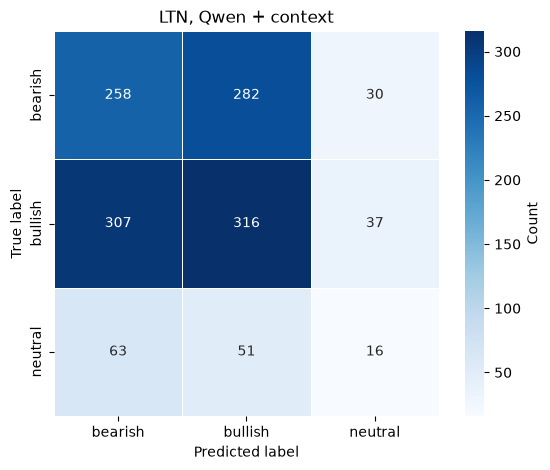

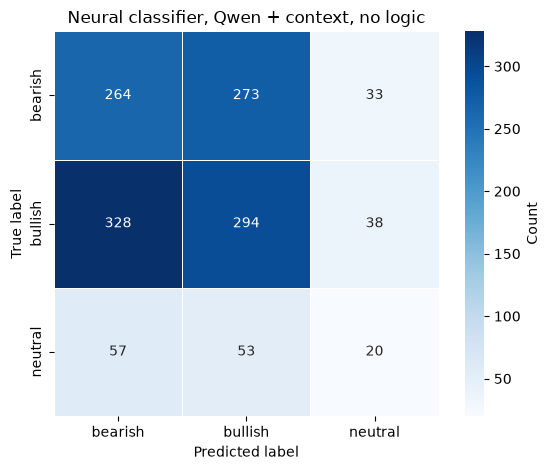

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion-matrix heatmaps from already-computed robust_confusion_tables.
# Counts only, no percentages.

for model_name, tables in robust_confusion_tables.items():
    counts = tables["counts"]

    plt.figure(figsize=(6, 4.8))

    sns.heatmap(
        counts,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar_kws={"label": "Count"},
        linewidths=0.5,
        linecolor="white",
        square=True,
    )

    plt.title(model_name)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()